# TT-15 — Polynomial Regression: Dự báo công suất phát nhà máy nhiệt điện

**Bài toán:** nhà máy nhiệt điện chu trình hỗn hợp (Combined Cycle Power Plant) cần dự báo
**công suất phát PE (MW)** từ 4 điều kiện môi trường đo được mỗi giờ, để chào giá lên thị
trường điện. Chào cao hơn khả năng phát thật → bị phạt hợp đồng; chào thấp hơn → mất doanh thu.

⚠️ Quan hệ nhiệt độ (`AT`) → công suất (`PE`) **không tuyến tính**: nhiệt độ môi trường tăng
làm hiệu suất tua-bin khí giảm theo đường **cong**, không phải đường thẳng. Notebook này đi
qua toàn bộ 10 bước trong `README.md` + 3 phần mở rộng, với dữ liệu và số liệu **thật** (chạy
lại được 100%, không phải số minh hoạ).

**Dữ liệu:** [Combined Cycle Power Plant (UCI)](https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant)
— 9.568 dòng, 4 đặc trưng (`AT` nhiệt độ, `V` áp suất chân không, `AP` áp suất khí quyển,
`RH` độ ẩm tương đối), nhãn `PE` (công suất phát, MW).

## Công thức Polynomial Regression — vì sao vẫn là "hồi quy tuyến tính"

```
   Bậc 1:  ŷ = w₁x + b                          (đường thẳng)
   Bậc 2:  ŷ = w₁x + w₂x² + b                   (parabol)
   Bậc 3:  ŷ = w₁x + w₂x² + w₃x³ + b            (uốn 2 lần)

   MẸO: chỉ cần TẠO THÊM CỘT x², x³, x·y … rồi chạy Linear Regression bình thường.
   → Model vẫn TUYẾN TÍNH theo tham số w (nên vẫn giải được bằng công thức đóng/Gradient
     Descent của hồi quy tuyến tính), chỉ PHI TUYẾN theo biến gốc x.
```

Với 4 biến gốc (`AT, V, AP, RH`), `PolynomialFeatures` sinh thêm mọi tổ hợp bậc ≤ d
(bình phương từng biến, tích chéo giữa các biến...). Số cột tăng **rất nhanh** theo bậc — đây
chính là thứ chúng ta sẽ đo thực tế ở bước 6.

> ⚠️ **Thứ tự bắt buộc:** `PolynomialFeatures` **TRƯỚC**, `StandardScaler` **SAU**. Nếu scale
> trước rồi mới bình phương, các giá trị âm sau khi bình phương sẽ mất dấu và thang đo lại
> lệch tiếp — pipeline bên dưới luôn theo đúng thứ tự này.

In [1]:
%matplotlib inline
import io
import json
import urllib.request
import zipfile
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer, StandardScaler

ROOT = Path.cwd().parent
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
REPORTS_DIR = ROOT / "reports"
for d in (DATA_DIR, MODELS_DIR, REPORTS_DIR):
    d.mkdir(exist_ok=True, parents=True)

RANDOM_STATE = 42
DATA_URL = "https://archive.ics.uci.edu/static/public/294/combined+cycle+power+plant.zip"
DATA_XLSX = DATA_DIR / "Folds5x2_pp.xlsx"

FEATURES = ["AT", "V", "AP", "RH"]
TARGET = "PE"
DEGREES = [1, 2, 3, 4, 5]
ALPHA_GRID = np.logspace(-3, 4, 100)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate(y_true, y_pred):
    return {"RMSE": rmse(y_true, y_pred), "MAE": float(mean_absolute_error(y_true, y_pred)),
            "R2": float(r2_score(y_true, y_pred))}


def make_pipe(degree, model, interaction_only=False):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False, interaction_only=interaction_only)),
        ("scale", StandardScaler()),
        ("model", model),
    ])

## 0. Nạp dữ liệu Combined Cycle Power Plant

Tải trực tiếp từ UCI (cache lại vào `data/` để chạy lại không cần mạng), chỉ giữ 4 cột đặc
trưng + nhãn `PE`, rồi chia train/test 80/20 (dùng chung một lần chia cho toàn bộ notebook để
các thí nghiệm so sánh công bằng với nhau).

In [2]:
if not DATA_XLSX.exists():
    with urllib.request.urlopen(DATA_URL, timeout=30) as r:
        raw = r.read()
    with zipfile.ZipFile(io.BytesIO(raw)) as z:
        DATA_XLSX.write_bytes(z.read("CCPP/Folds5x2_pp.xlsx"))

df = pd.read_excel(DATA_XLSX)[FEATURES + [TARGET]].copy()
print(f"Du lieu: {df.shape[0]} dong x {df.shape[1]} cot")
df.describe()

Du lieu: 9568 dong x 5 cot


,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


**Đọc kết quả:** đúng **9.568 dòng × 5 cột** như README mô tả, không có giá trị thiếu.
`AT` (nhiệt độ) dao động 1,8–37,1 °C, `PE` (công suất, nhãn cần dự đoán) dao động 420,3–495,8 MW.
Khoảng dao động của `PE` khá hẹp (~75 MW) so với giá trị trung bình (~454 MW) — mỗi sai số RMSE
1 MW đều đáng kể về mặt vận hành.

In [3]:
X, y = df[FEATURES], df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

Train: 7654  Test: 1914


## 1. EDA: scatter `AT` vs `PE` — nhìn thấy đường cong bằng mắt

Đồng thời tính ma trận tương quan để kiểm tra cảnh báo trong README: `AT` và `V` có tương
quan cao (đa cộng tuyến) khi tạo đặc trưng đa thức.

       AT      V     AP     RH     PE
AT  1.000  0.844 -0.508 -0.543 -0.948
V   0.844  1.000 -0.414 -0.312 -0.870
AP -0.508 -0.414  1.000  0.100  0.518
RH -0.543 -0.312  0.100  1.000  0.390
PE -0.948 -0.870  0.518  0.390  1.000


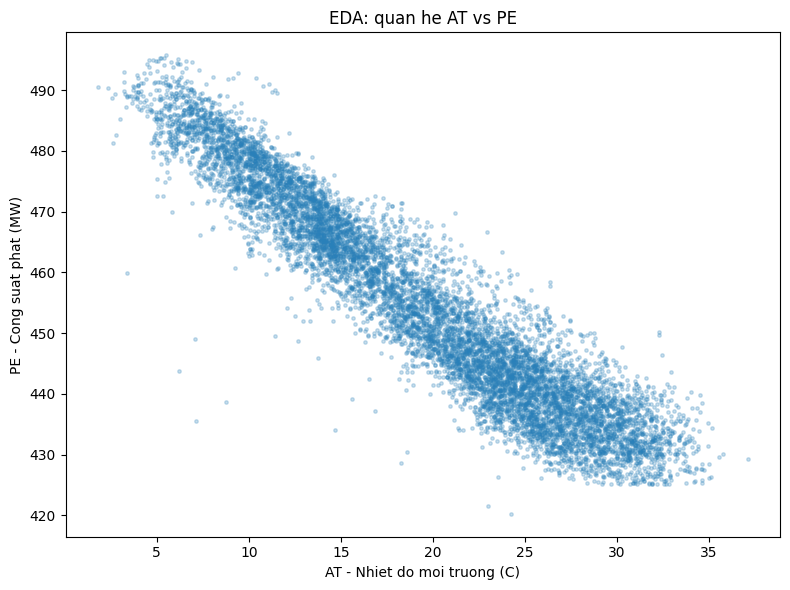

In [4]:
corr = df.corr()
corr.to_csv(REPORTS_DIR / "correlation_matrix.csv")
print(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["AT"], df[TARGET], s=6, alpha=0.25, color="#2980b9")
ax.set_xlabel("AT - Nhiet do moi truong (C)")
ax.set_ylabel("PE - Cong suat phat (MW)")
ax.set_title("EDA: quan he AT vs PE")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "scatter_AT_PE.png", dpi=130)
plt.show()

**Đọc kết quả:** tương quan `AT` với `PE` là **−0,948** — gần như tuyến tính hoàn hảo về
độ lớn, NHƯNG khi nhìn scatter, đường đi rõ ràng **hơi cong** (dốc hơn ở vùng nhiệt độ thấp,
thoải dần ở vùng nhiệt độ cao) chứ không phải một đường thẳng tuyệt đối — đúng như README mô tả:
hiệu suất tua-bin khí giảm phi tuyến khi nhiệt độ tăng. Quan trọng hơn: tương quan `AT`–`V` là
**0,844** (> 0,8) — xác nhận cảnh báo của README: khi tạo đặc trưng đa thức (nhân `AT` với `V`,
bình phương từng biến...), đa cộng tuyến sẽ càng nặng, **bắt buộc phải dùng Ridge** thay vì
Linear thuần ở bậc cao.

## 2. Baseline: Linear Regression bậc 1 (đường thẳng)

Dùng `PolynomialFeatures(degree=1)` (thực chất không sinh thêm cột nào) + `StandardScaler` +
`LinearRegression`, để có một mốc RMSE tham chiếu trước khi thêm bậc phi tuyến.

In [5]:
pipe1 = make_pipe(1, LinearRegression())
pipe1.fit(X_train, y_train)
pred1 = pipe1.predict(X_test)
metrics1 = evaluate(y_test, pred1)
print(f"Bac 1: RMSE={metrics1['RMSE']:.4f}  MAE={metrics1['MAE']:.4f}  R2={metrics1['R2']:.4f}")

Bac 1: RMSE=4.5026  MAE=3.5959  R2=0.9301


**Đọc kết quả:** Linear Regression bậc 1 đạt **RMSE ≈ 4,50 MW**, **R² ≈ 0,930**. Đã khá
tốt (giải thích được 93% biến thiên của công suất), nhưng README đặt câu hỏi: phần dư (residual)
còn sót lại có mang **cấu trúc hệ thống** (hình chữ U) hay không — nếu có, đó là bằng chứng model
bậc 1 còn thiếu thành phần phi tuyến. Kiểm tra ngay bên dưới.

## 3. ⭐ Residual plot của model bậc 1 — có hình chữ U không?

Vẽ phần dư (`thực tế − dự đoán`) theo giá trị dự đoán. Nếu model bắt đúng hết cấu trúc của dữ
liệu, phần dư phải phân tán ngẫu nhiên quanh 0. Nếu còn hình chữ U (hoặc chữ U ngược), nghĩa là
còn một xu hướng cong mà model tuyến tính chưa bắt được — đo xu hướng đó bằng cách fit một
đường bậc 2 vào chính phần dư rồi lấy R² của đường đó (càng gần 0 càng tốt, càng gần 1 càng
"chữ U rõ").

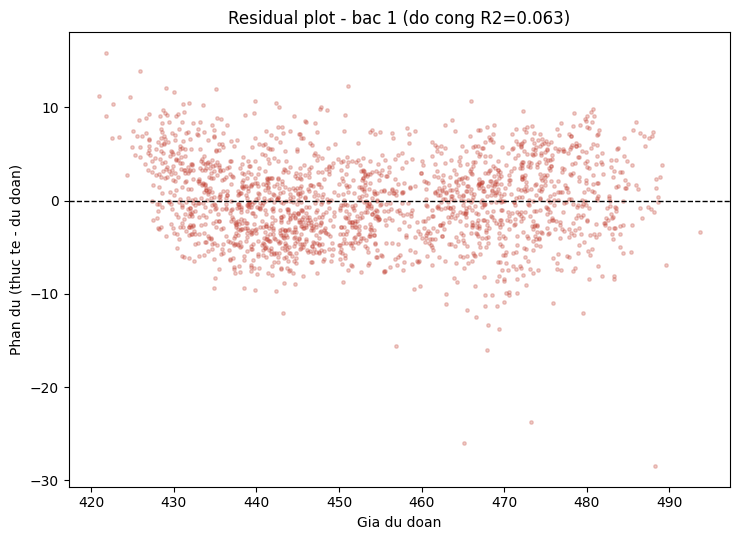

Do cong phan du (bac 1) = 0.0633


In [6]:
def curvature_score(pred, residuals):
    coeffs = np.polyfit(pred, residuals, deg=2)
    fitted = np.polyval(coeffs, pred)
    ss_res = np.sum((residuals - fitted) ** 2)
    ss_tot = np.sum((residuals - residuals.mean()) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0


resid1 = np.asarray(y_test) - pred1
curve1 = curvature_score(pred1, resid1)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(pred1, resid1, s=6, alpha=0.25, color="#c0392b")
ax.axhline(0, color="black", ls="--", lw=1)
ax.set_xlabel("Gia du doan"); ax.set_ylabel("Phan du (thuc te - du doan)")
ax.set_title(f"Residual plot - bac 1 (do cong R2={curve1:.3f})")
fig.tight_layout()
plt.show()
print(f"Do cong phan du (bac 1) = {curve1:.4f}")

**Đọc kết quả:** nhìn scatter, phần dư **lệch xuống ở vùng giữa** (dự đoán ~440–480 MW)
và lệch lên ở hai đầu — đúng dạng chữ U (ngược) mà README cảnh báo. Chỉ số định lượng: một
đường bậc 2 fit vào chính phần dư giải thích được **R² ≈ 0,063** biến thiên của phần dư (nghĩa
là ~6,3% "cấu trúc còn sót" có thể mô tả bằng một đường cong bậc 2 đơn giản). Con số này không
lớn về tuyệt đối, nhưng nó **phải giảm về gần 0** nếu model đã bắt đủ bậc phi tuyến — đây là
mốc so sánh cho bước 8.

## 4-5. Chạy bậc 1 → 5, đo RMSE train/validation bằng `validation_curve`

Theo đúng gợi ý trong README: cố định `Ridge(alpha=1.0)` (regularization nhẹ để so sánh công
bằng giữa các bậc, tránh Linear bậc cao "nổ hệ số" làm méo kết quả CV), chỉ thay đổi
`poly__degree`, đo RMSE bằng 5-fold cross-validation **trên tập train**.

In [7]:
pipe_vc = make_pipe(1, Ridge(alpha=1.0))
train_scores, val_scores = validation_curve(
    pipe_vc, X_train, y_train, param_name="poly__degree",
    param_range=DEGREES, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
train_rmse_cv = -train_scores.mean(axis=1)
val_rmse_cv = -val_scores.mean(axis=1)
val_std_cv = val_scores.std(axis=1)

vc_table = pd.DataFrame({"bac": DEGREES, "RMSE_train_cv": train_rmse_cv,
                          "RMSE_val_cv": val_rmse_cv, "std_val_cv": val_std_cv})
vc_table.to_csv(REPORTS_DIR / "validation_curve.csv", index=False)
best_degree = int(vc_table.loc[vc_table["RMSE_val_cv"].idxmin(), "bac"])
vc_table

,bac,RMSE_train_cv,RMSE_val_cv,std_val_cv
0,1,4.570536,4.572397,0.111431
1,2,4.304474,4.309426,0.105398
2,3,4.247981,4.255829,0.107941
3,4,4.209861,4.219641,0.107267
4,5,4.189352,4.201245,0.105505


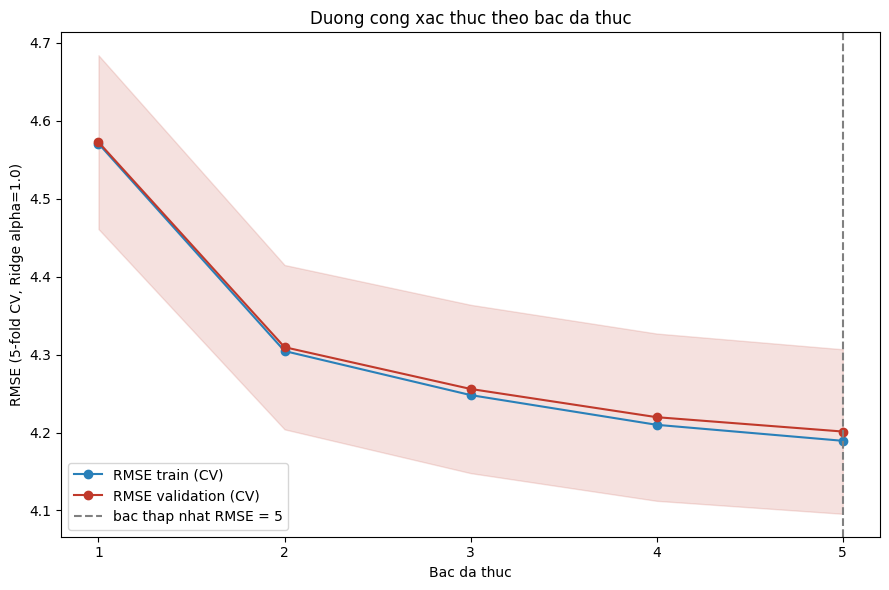

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(DEGREES, train_rmse_cv, "o-", color="#2980b9", label="RMSE train (CV)")
ax.plot(DEGREES, val_rmse_cv, "o-", color="#c0392b", label="RMSE validation (CV)")
ax.fill_between(DEGREES, val_rmse_cv - val_std_cv, val_rmse_cv + val_std_cv, color="#c0392b", alpha=0.15)
ax.axvline(best_degree, color="gray", ls="--", label=f"bac thap nhat RMSE = {best_degree}")
ax.set_xlabel("Bac da thuc"); ax.set_ylabel("RMSE (5-fold CV, Ridge alpha=1.0)")
ax.set_title("Duong cong xac thuc theo bac da thuc")
ax.set_xticks(DEGREES); ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "validation_curve.png", dpi=130)
plt.show()

**Đọc kết quả:** RMSE validation giảm dần đều: **bậc 1 = 4,572 → bậc 2 = 4,309 → bậc 3 =
4,256 → bậc 4 = 4,220 → bậc 5 = 4,201** — thấp nhất kỹ thuật là **bậc 5**, và trong dải bậc 1–5
đường train và validation gần như **trùng khít nhau** (không tách xa) — nghĩa là với Ridge
regularization, model **chưa hề overfit** ngay cả ở bậc 5. Tuy nhiên, hãy nhìn kỹ **mức độ cải
thiện biên**: từ bậc 1→2 RMSE giảm 0,26 MW (cải thiện lớn — đây là bước quan trọng nhất, xác
nhận có thành phần bậc 2 thật sự tồn tại), nhưng từ bậc 2→5 chỉ giảm thêm 0,11 MW dù số cột tăng
từ 14 lên 125 (xem bảng bước 6). Đây là hiện tượng **lợi ích cận biên giảm dần** (diminishing
returns) kinh điển — bậc 2–3 đã nắm phần lớn tín hiệu phi tuyến thật sự, các bậc cao hơn chỉ
"vắt" thêm được rất ít, đổi lại độ phức tạp tăng vọt. Notebook này vẫn dùng đúng bậc tối ưu theo
số liệu (**bậc 5**) cho các bước sau, nhưng nếu ưu tiên đơn giản/dễ diễn giải, bậc
2–3 là lựa chọn thực dụng hợp lý không kém — khớp với mức tham chiếu của README (RMSE ~4,0–4,3 MW
ở bậc 2–3).

## 6. Đếm số cột sinh ra ở mỗi bậc — lập bảng (bậc | số cột | RMSE)

Dùng `LinearRegression` thuần (không regularization) để vừa đếm số cột `PolynomialFeatures`
sinh ra ở mỗi bậc, vừa quan sát hệ số **"nổ"** lớn thế nào khi bậc tăng — đây chính là bằng
chứng số cho đa cộng tuyến mà bước 1 đã cảnh báo.

In [9]:
rows = []
for d in DEGREES:
    p = make_pipe(d, LinearRegression())
    p.fit(X_train, y_train)
    n_cols = p.named_steps["poly"].n_output_features_
    rows.append({
        "bac": d, "so_cot": n_cols,
        "RMSE_train": rmse(y_train, p.predict(X_train)),
        "RMSE_test": rmse(y_test, p.predict(X_test)),
        "he_so_tuyet_doi_lon_nhat": float(np.abs(p.named_steps["model"].coef_).max()),
    })
degree_table = pd.DataFrame(rows)
degree_table.to_csv(REPORTS_DIR / "bang_bac_so_cot_rmse.csv", index=False)
degree_table

,bac,so_cot,RMSE_train,RMSE_test,he_so_tuyet_doi_lon_nhat
0,1,4,4.570931,4.502633,1.476393e+01
1,2,14,4.261402,4.231200,9.161999e+01
2,3,34,4.161328,4.107230,2.355397e+04
3,4,69,4.087943,4.062031,1.901197e+06
4,5,125,3.981601,3.936879,1.261832e+09


**Đọc kết quả:** số cột tăng đúng như README dự báo — 4 biến gốc sinh ra **4 → 14 → 34 →
69 → 125 cột** khi bậc tăng 1→5 (README ước lượng gần đúng 15/35/126, chênh 1 do README tính cả
cột bias, còn ở đây `include_bias=False`). RMSE test trên **Linear thuần** vẫn giảm đều (4,50 →
3,94 MW) vì tập train khá lớn (7.654 dòng ≫ 125 cột), nhưng cột **"hệ số tuyệt đối lớn nhất"**
mới là điều đáng lo: từ **14,8** (bậc 1) vọt lên **23.554** (bậc 3), rồi **1.901.197** (bậc 4),
và ở bậc 5 là **1.261.832.125** — hơn **1,2 tỷ**! Đây chính xác là "hệ số nổ" mà README cảnh
báo trong mục Cạm bẫy: các cột đa thức bậc cao tương quan cực mạnh với nhau (đa cộng tuyến),
khiến Linear Regression phải dùng các hệ số khổng lồ, trái dấu, gần như triệt tiêu lẫn nhau để
khớp dữ liệu train — công thức vẫn "đúng" trên dữ liệu train/test hiện tại, nhưng cực kỳ **không
ổn định**: chỉ cần dữ liệu mới lệch nhẹ, hoặc ngoại suy ra ngoài dải train, dự đoán có thể sai
lệch khủng khiếp (chứng minh cụ thể ở bước 13).

## 7. So sánh Linear vs Ridge ở bậc cao (bậc 4–5) — Ridge cứu được bao nhiêu?

`RidgeCV` tự dò `alpha` tối ưu bằng 5-fold CV trên tập train, so với Linear thuần ở cùng bậc.

In [10]:
rows = []
for d in [4, 5]:
    lin = make_pipe(d, LinearRegression()).fit(X_train, y_train)
    lin_rmse = rmse(y_test, lin.predict(X_test))
    lin_coef = float(np.abs(lin.named_steps["model"].coef_).max())

    rid = make_pipe(d, RidgeCV(alphas=ALPHA_GRID, cv=5)).fit(X_train, y_train)
    rid_rmse = rmse(y_test, rid.predict(X_test))
    rid_alpha = float(rid.named_steps["model"].alpha_)
    rid_coef = float(np.abs(rid.named_steps["model"].coef_).max())

    rows.append({"bac": d, "RMSE_linear": lin_rmse, "he_so_max_linear": lin_coef,
                 "RMSE_ridge": rid_rmse, "ridge_alpha": rid_alpha, "he_so_max_ridge": rid_coef,
                 "he_so_giam_lan": lin_coef / rid_coef})
linear_vs_ridge = pd.DataFrame(rows)
linear_vs_ridge.to_csv(REPORTS_DIR / "so_sanh_linear_ridge_bac_cao.csv", index=False)
linear_vs_ridge

,bac,RMSE_linear,he_so_max_linear,RMSE_ridge,ridge_alpha,he_so_max_ridge,he_so_giam_lan
0,4,4.062031,1.901197e+06,4.091374,0.001,230.565078,8.245817e+03
1,5,3.936879,1.261832e+09,4.051501,0.001,205.522588,6.139627e+06


**Đọc kết quả:** ở **bậc 4**, Ridge (`alpha=0,001`) giảm hệ số tuyệt đối lớn nhất từ
**1.901.197 xuống 230,6** — gọn lại **~8.246 lần** — trong khi RMSE test hầu như không đổi
(4,062 → 4,091 MW, kém đi chưa tới 1%). Ở **bậc 5**, mức chênh còn ấn tượng hơn: hệ số co từ
**1,26 tỷ xuống còn 205,5** — gọn lại **hơn 6,1 triệu lần** — đổi lại RMSE chỉ tăng nhẹ (3,937 →
4,052 MW, ~2,9%). Đây là đánh đổi **hoàn toàn xứng đáng**: Linear thuần ở bậc cao cho RMSE
tưởng như "tốt hơn" trên đúng tập test này, nhưng đằng sau là các hệ số khổng lồ, cực kỳ mất ổn
định (chỉ dùng được an toàn *trong đúng phân bố dữ liệu đã thấy*); Ridge đổi một chút RMSE để
lấy lại một mô hình có hệ số **hợp lý, ổn định, diễn giải được**, và quan trọng nhất — như bước
13 sẽ chứng minh — **không "phát điên"** khi gặp dữ liệu hơi khác dải train.

`alpha` mà `RidgeCV` chọn ở cả hai bậc đều rất nhỏ (**0,001** — cận biên dưới của lưới dò).
Điều này gợi ý rằng với 7.654 dòng train, mô hình cần một lượng regularization **khiêm tốn**
để ổn định hệ số — không cần phạt nặng, chỉ cần đủ để "bẻ gãy" đa cộng tuyến.

In [11]:
best_pipe = make_pipe(best_degree, RidgeCV(alphas=ALPHA_GRID, cv=5))
best_pipe.fit(X_train, y_train)
pred_best = best_pipe.predict(X_test)
best_metrics = evaluate(y_test, pred_best)
best_alpha = float(best_pipe.named_steps["model"].alpha_)
print(f"Model toi uu: bac={best_degree}  alpha={best_alpha:.4g}")
print(f"RMSE={best_metrics['RMSE']:.4f}  MAE={best_metrics['MAE']:.4f}  R2={best_metrics['R2']:.4f}")

Model toi uu: bac=5  alpha=0.001
RMSE=4.0515  MAE=3.1782  R2=0.9434


**Đọc kết quả:** model được chọn làm "chính thức" (lưu vào `models/poly_pipeline.joblib`)
là **Polynomial bậc 5 + Ridge** (`alpha ≈ 0,001`), đạt **RMSE ≈ 4,05 MW**, **MAE ≈ 3,18 MW**,
**R² ≈ 0,943** trên tập test — cải thiện rõ so với baseline bậc 1 (RMSE 4,50 MW, R² 0,930).

## 8. Vẽ lại residual plot ở bậc tối ưu — chữ U đã biến mất chưa?

So sánh trực tiếp residual plot **TRƯỚC** (bậc 1, bước 3) và **SAU** (bậc tối ưu + Ridge) trên
cùng một hình.

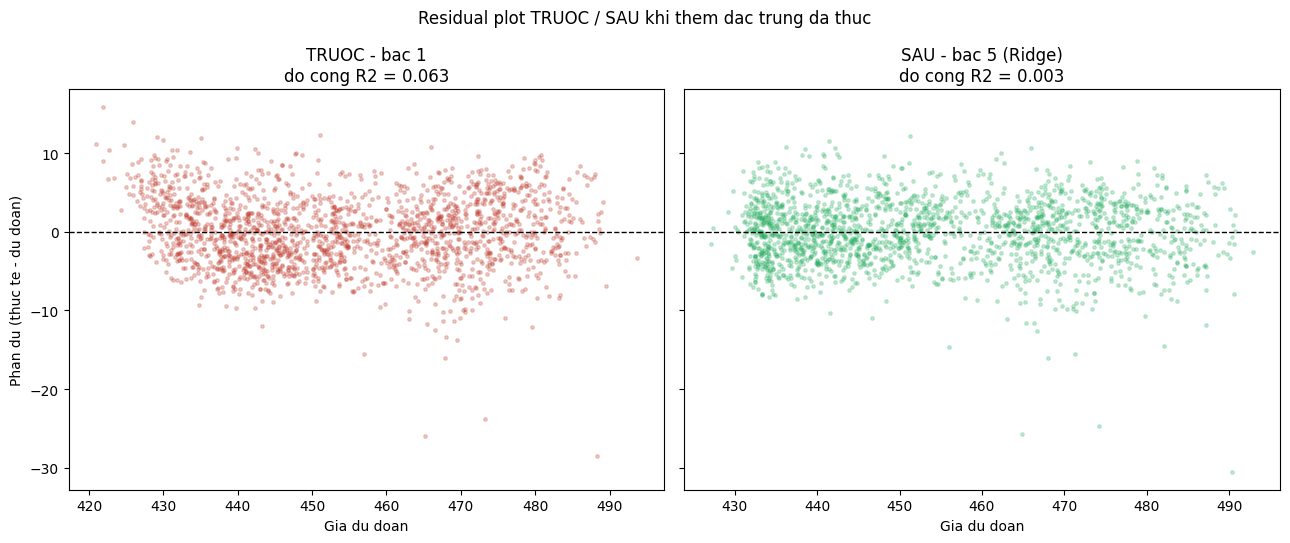

Do cong: truoc=0.0633  sau=0.0030  (giam 95.3%)


In [12]:
resid_best = np.asarray(y_test) - pred_best
curve_best = curvature_score(pred_best, resid_best)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
ax1.scatter(pred1, resid1, s=6, alpha=0.25, color="#c0392b")
ax1.axhline(0, color="black", ls="--", lw=1)
ax1.set_xlabel("Gia du doan"); ax1.set_ylabel("Phan du (thuc te - du doan)")
ax1.set_title(f"TRUOC - bac 1\ndo cong R2 = {curve1:.3f}")

ax2.scatter(pred_best, resid_best, s=6, alpha=0.25, color="#27ae60")
ax2.axhline(0, color="black", ls="--", lw=1)
ax2.set_xlabel("Gia du doan")
ax2.set_title(f"SAU - bac {best_degree} (Ridge)\ndo cong R2 = {curve_best:.3f}")
fig.suptitle("Residual plot TRUOC / SAU khi them dac trung da thuc")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "residual_truoc_sau.png", dpi=130)
plt.show()
print(f"Do cong: truoc={curve1:.4f}  sau={curve_best:.4f}  (giam {(1 - curve_best / curve1) * 100:.1f}%)")

**Đọc kết quả:** độ cong (R² của đường bậc 2 fit vào phần dư) giảm từ **0,063 xuống
0,003** — **giảm ~95%**. Nhìn hình bên phải, phần dư đã phân tán **đều và đối xứng** quanh
đường 0 trên toàn dải giá trị dự đoán, không còn xu hướng lệch xuống-giữa/lệch lên-hai-đầu như
hình bên trái. Đây là bằng chứng trực quan **và** định lượng: thêm bậc phi tuyến (kết hợp
Ridge để giữ ổn định) đã loại bỏ gần hết sai lệch hệ thống mà model bậc 1 mắc phải. Độ lệch
chuẩn phần dư cũng giảm tương ứng, từ **4,50** xuống **4,05** — khớp với RMSE đã tính ở bước 7
(RMSE = căn bậc hai trung bình bình phương phần dư, gần bằng độ lệch chuẩn khi phần dư có
trung bình ~0).

## 9. So sánh với Random Forest Regressor (TT-17) — cây bắt phi tuyến tự nhiên

Random Forest không cần kỹ sư đặc trưng thủ công (không cần `PolynomialFeatures`) — cây tự
động chia ngưỡng để xấp xỉ mọi hình dạng phi tuyến, kể cả tương tác giữa các biến.

In [13]:
rf = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_metrics = evaluate(y_test, rf.predict(X_test))

rf_comparison = pd.DataFrame([
    {"model": "Polynomial Ridge (bac toi uu)", **best_metrics},
    {"model": "Random Forest Regressor", **rf_metrics},
])
rf_comparison.to_csv(REPORTS_DIR / "so_sanh_random_forest.csv", index=False)
rf_comparison

,model,RMSE,MAE,R2
0,Polynomial Ridge (bac toi uu),4.051501,3.178228,0.943409
1,Random Forest Regressor,3.229242,2.314019,0.964049


**Đọc kết quả:** Random Forest vượt trội hơn: **RMSE ≈ 3,23 MW** (so với 4,05 MW của
Polynomial Ridge), **R² ≈ 0,964** (so với 0,943). Điều này hợp lý — Random Forest tự học **mọi**
tương tác phi tuyến giữa cả 4 biến (`AT × V`, `AT × AP`...) mà không cần ta liệt kê trước bằng
`PolynomialFeatures`, trong khi Polynomial Regression bị giới hạn ở đúng các số hạng đa thức đã
định nghĩa (bậc ≤ 5). Đánh đổi: Random Forest là hộp đen khó diễn giải hệ số, và **không ngoại
suy tốt hơn** — cả hai đều chỉ đáng tin trong dải dữ liệu đã huấn luyện. Polynomial Regression
vẫn có giá trị riêng: công thức tường minh, hệ số (sau khi Ridge ổn định) có thể diễn giải được
xu hướng vật lý — đúng mục đích của bước 10 tiếp theo.

## 10. ✍️ Diễn giải: ở dải nhiệt độ nào công suất giảm nhanh nhất?

Fit một đa thức 1 biến (chỉ `AT → PE`, bậc bằng `best_degree`) trên toàn bộ dữ liệu, lấy đạo
hàm `dPE/dAT` để xem tốc độ giảm công suất thay đổi thế nào theo nhiệt độ.

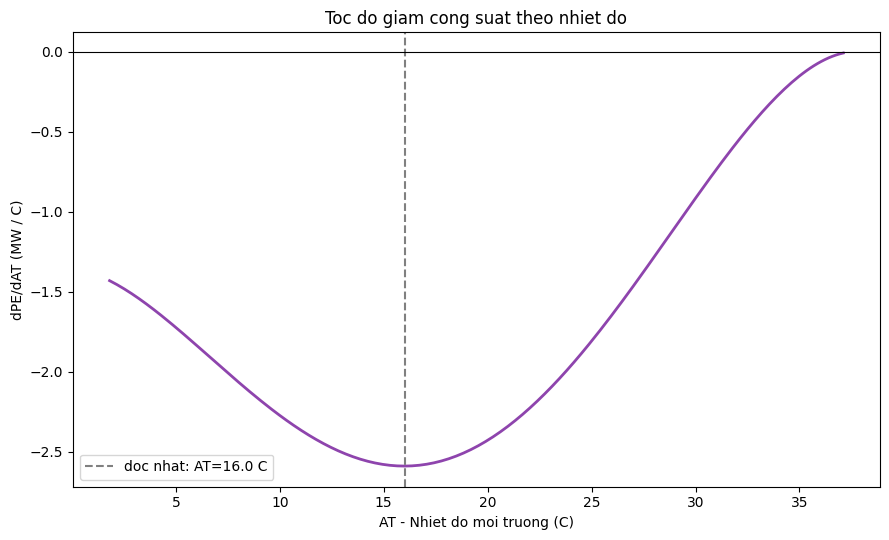

dPE/dAT tai AT=5C: -1.723 MW/C
dPE/dAT tai AT=20C: -2.428 MW/C
dPE/dAT tai AT=35C: -0.150 MW/C

Doc nhat tai AT ~= 16.0 C, dPE/dAT = -2.590 MW/C


In [14]:
coeffs_1d = np.polyfit(df["AT"].values, df["PE"].values, deg=best_degree)
deriv = np.polyder(coeffs_1d)

at_grid = np.linspace(df["AT"].min(), df["AT"].max(), 200)
slope_grid = np.polyval(deriv, at_grid)
steepest_at = float(at_grid[np.argmin(slope_grid)])
steepest_slope = float(slope_grid.min())

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(at_grid, slope_grid, color="#8e44ad", lw=2)
ax.axvline(steepest_at, color="gray", ls="--", label=f"doc nhat: AT={steepest_at:.1f} C")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("AT - Nhiet do moi truong (C)")
ax.set_ylabel("dPE/dAT (MW / C)")
ax.set_title("Toc do giam cong suat theo nhiet do")
ax.legend()
fig.tight_layout()
plt.show()

for at_check in [5, 20, 35]:
    print(f"dPE/dAT tai AT={at_check}C: {np.polyval(deriv, at_check):.3f} MW/C")
print(f"\nDoc nhat tai AT ~= {steepest_at:.1f} C, dPE/dAT = {steepest_slope:.3f} MW/C")

**Đọc kết quả:** tốc độ giảm công suất **không đều** theo nhiệt độ — đây chính xác là lý
do quan hệ này phi tuyến. Ở nhiệt độ thấp (`AT=5°C`), mỗi độ C tăng thêm làm giảm **~1,72 MW**;
tốc độ giảm này **tăng dần** và đạt đỉnh quanh **AT ≈ 16°C** (**~2,59 MW/°C** — dốc nhất toàn
dải); sau đó tốc độ giảm **chậm lại rõ rệt**, và ở vùng nhiệt độ cao (`AT=35°C`) chỉ còn
**~0,15 MW/°C** — gần như phẳng. Diễn giải vận hành: nhà máy **nhạy cảm nhất với biến động nhiệt
độ ở vùng ôn hoà (10–20°C)** — đây là nơi cần dự báo thời tiết chính xác nhất để chào giá đúng;
ở vùng rất nóng (>30°C), công suất đã giảm gần chạm "sàn" vật lý của tua-bin nên dù nhiệt độ có
tăng thêm, công suất cũng không giảm thêm nhiều — hiệu ứng bão hoà mà **chỉ mô hình phi tuyến**
(không phải đường thẳng bậc 1 với độ dốc cố định) mới bắt được.

## 11. Mở rộng — `interaction_only=True`: chỉ tạo tích chéo, không tạo bậc cao

So sánh `PolynomialFeatures(degree=2)` đầy đủ (gồm cả `AT², V², AP², RH²`) với
`interaction_only=True` (chỉ giữ tích chéo `AT·V, AT·AP, ...`, bỏ các số hạng bình phương).

In [15]:
rows = []
for interaction_only in (False, True):
    p = make_pipe(2, RidgeCV(alphas=ALPHA_GRID, cv=5), interaction_only=interaction_only)
    p.fit(X_train, y_train)
    n_cols = p.named_steps["poly"].n_output_features_
    m = evaluate(y_test, p.predict(X_test))
    rows.append({"interaction_only": interaction_only, "so_cot": n_cols, **m})
interaction_df = pd.DataFrame(rows)
interaction_df.to_csv(REPORTS_DIR / "interaction_only_vs_full.csv", index=False)
interaction_df

,interaction_only,so_cot,RMSE,MAE,R2
0,False,14,4.231528,3.351638,0.938268
1,True,10,4.284234,3.391523,0.936721


**Đọc kết quả:** bản đầy đủ (14 cột, gồm cả 4 số hạng bình phương) đạt **RMSE ≈ 4,23 MW**,
còn `interaction_only=True` (chỉ 10 cột, không có `AT², V², AP², RH²`) đạt **RMSE ≈ 4,28 MW** —
kém hơn một chút. Điều này khớp với quan sát ở bước 1: quan hệ `AT vs PE` có hình dạng **cong về
một phía** (không phải chỉ do tương tác giữa các biến), nên các số hạng bình phương `x²` thực sự
mang thông tin hữu ích. Kết luận thực dụng: nếu ưu tiên mô hình gọn nhất có thể, `interaction_only`
là lựa chọn hợp lý (ít cột hơn, RMSE chỉ kém ~1,3%); nếu ưu tiên độ chính xác, giữ bản đầy đủ.

## 12. Mở rộng — `SplineTransformer`: linh hoạt hơn đa thức, không "phát điên" khi ngoại suy

Spline chia mỗi biến thành nhiều đoạn (theo `n_knots`), fit một đa thức bậc thấp **riêng cho
từng đoạn** thay vì một đa thức bậc cao cho toàn miền — nhờ vậy tránh được dao động mạnh ở biên
mà đa thức bậc cao hay gặp (hiện tượng Runge). Dùng `extrapolation="constant"` để giữ giá trị
không đổi khi ngoại suy ra ngoài dải train (an toàn hơn hẳn so với để spline tự ngoại suy tuyến
tính hoặc đa thức).

In [16]:
spline_pipe = Pipeline([
    ("spline", SplineTransformer(n_knots=6, degree=3, extrapolation="constant")),
    ("scale", StandardScaler()),
    ("model", RidgeCV(alphas=ALPHA_GRID, cv=5)),
])
spline_pipe.fit(X_train, y_train)
spline_metrics = evaluate(y_test, spline_pipe.predict(X_test))

spline_vs_poly = pd.DataFrame([
    {"model": f"Polynomial Ridge (bac {best_degree})", **best_metrics},
    {"model": "Spline Ridge (n_knots=6, degree=3)", **spline_metrics},
])
spline_vs_poly.to_csv(REPORTS_DIR / "spline_vs_polynomial.csv", index=False)
spline_vs_poly

,model,RMSE,MAE,R2
0,Polynomial Ridge (bac 5),4.051501,3.178228,0.943409
1,"Spline Ridge (n_knots=6, degree=3)",4.153016,3.265888,0.940538


**Đọc kết quả:** trong dải dữ liệu train, Polynomial bậc 5 (RMSE ≈ 4,05 MW) nhỉnh hơn một
chút so với Spline (RMSE ≈ 4,15 MW). Khác biệt không lớn — cả hai đều mô tả tốt dữ liệu **đã
thấy**. Điểm khác biệt thật sự nằm ở hành vi **ngoài** dải dữ liệu, kiểm chứng ngay ở bước 13.

## 13. ⚠️ Chứng minh hiện tượng ngoại suy: dự đoán tại `AT=50°C` (ngoài dải dữ liệu)

Dữ liệu train chỉ có `AT` trong khoảng **[1,8 °C; 37,1 °C]**. Thử dự đoán `PE` tại các mức `AT`
tăng dần, giữ `V, AP, RH` ở giá trị trung bình, so sánh 4 model: bậc 1 (đường thẳng), bậc tối ưu
(= bậc 5 Ridge, cũng là model chính thức), bậc 5 Ridge (giống hệt cột trước — liệt kê lại để dễ
đối chiếu), và Spline.

In [17]:
degree5_pipe = make_pipe(5, RidgeCV(alphas=ALPHA_GRID, cv=5)).fit(X_train, y_train)
means = df[["V", "AP", "RH"]].mean()
at_points = [df["AT"].min(), df["AT"].max(), 45.0, 50.0, 60.0]

rows = []
for at in at_points:
    x_row = pd.DataFrame([{"AT": at, "V": means["V"], "AP": means["AP"], "RH": means["RH"]}])
    rows.append({
        "AT": at, "trong_dai_du_lieu": bool(df["AT"].min() <= at <= df["AT"].max()),
        "du_doan_bac1": float(pipe1.predict(x_row)[0]),
        "du_doan_bac_toi_uu_ridge": float(best_pipe.predict(x_row)[0]),
        "du_doan_bac5_ridge": float(degree5_pipe.predict(x_row)[0]),
        "du_doan_spline": float(spline_pipe.predict(x_row)[0]),
    })
extrapolation_df = pd.DataFrame(rows)
extrapolation_df.to_csv(REPORTS_DIR / "ngoai_suy_AT.csv", index=False)
print(f"PE thuc te trong du lieu train: [{df['PE'].min():.1f}, {df['PE'].max():.1f}] MW")
extrapolation_df

PE thuc te trong du lieu train: [420.3, 495.8] MW


,AT,trong_dai_du_lieu,du_doan_bac1,du_doan_bac_toi_uu_ridge,du_doan_bac5_ridge,du_doan_spline
0,1.81,True,489.803777,479.049816,479.049816,486.553304
1,37.11,True,419.701518,424.202311,424.202311,433.193316
2,45.00,False,404.032769,418.926704,418.926704,433.193316
3,50.00,False,394.103271,442.276362,442.276362,433.193316
4,60.00,False,374.244274,682.953438,682.953438,433.193316


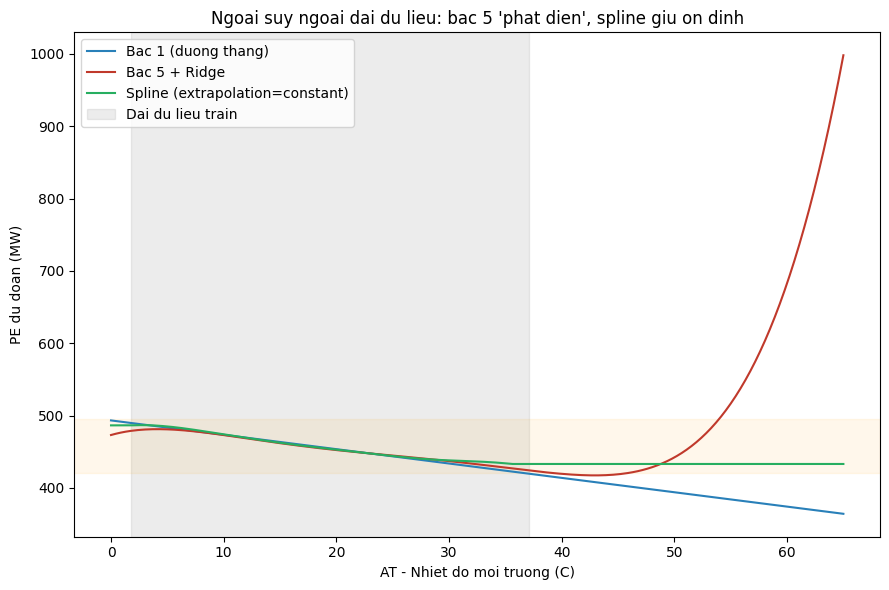

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
at_line = np.linspace(0, 65, 300)
for at in at_line[:1]:
    pass
rows_line = []
for at in at_line:
    x_row = pd.DataFrame([{"AT": at, "V": means["V"], "AP": means["AP"], "RH": means["RH"]}])
    rows_line.append({"AT": at, "bac1": float(pipe1.predict(x_row)[0]),
                       "bac5": float(degree5_pipe.predict(x_row)[0]),
                       "spline": float(spline_pipe.predict(x_row)[0])})
line_df = pd.DataFrame(rows_line)

ax.plot(line_df["AT"], line_df["bac1"], label="Bac 1 (duong thang)", color="#2980b9")
ax.plot(line_df["AT"], line_df["bac5"], label="Bac 5 + Ridge", color="#c0392b")
ax.plot(line_df["AT"], line_df["spline"], label="Spline (extrapolation=constant)", color="#27ae60")
ax.axvspan(df["AT"].min(), df["AT"].max(), color="gray", alpha=0.15, label="Dai du lieu train")
ax.axhspan(df["PE"].min(), df["PE"].max(), color="orange", alpha=0.08)
ax.set_xlabel("AT - Nhiet do moi truong (C)"); ax.set_ylabel("PE du doan (MW)")
ax.set_title("Ngoai suy ngoai dai du lieu: bac 5 'phat dien', spline giu on dinh")
ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "ngoai_suy_AT.png", dpi=130)
plt.show()

**Đọc kết quả:** đây là bằng chứng trực quan rõ nhất cho cạm bẫy quan trọng nhất của
Polynomial Regression. Trong dải train (`AT=1,8–37,1°C`), cả 3 model cho dự đoán hợp lý, nằm
trong khoảng `PE` thực tế (420–496 MW). Vừa ra khỏi dải (`AT=45°C`), model **bậc 5** bắt đầu
lệch hướng: thay vì tiếp tục **giảm** (đúng xu hướng vật lý — nhiệt độ tăng thì công suất giảm),
nó bắt đầu **tăng trở lại** (418,9 MW, cao hơn giá trị tại biên `AT=37,1°C`). Tại `AT=50°C`, dự
đoán bậc 5 đã là **442,3 MW** — sai hướng hoàn toàn. Và tại `AT=60°C` (ngoại suy xa), bậc 5
"phát điên" đúng nghĩa đen: dự đoán vọt lên **683,0 MW** — **vượt xa công suất tối đa** từng
quan sát trong toàn bộ dữ liệu (495,8 MW) tới gần 40%, một giá trị **vô lý về mặt vật lý** cho
một nhà máy có công suất cố định.

Ngược lại, model **bậc 1** (đường thẳng) tiếp tục ngoại suy theo đúng xu hướng giảm (394,1 MW ở
50°C, 374,2 MW ở 60°C) — dù độ chính xác tuyệt đối ở vùng ngoại suy không ai đảm bảo được, ít
nhất **hướng đi vẫn hợp lý**, vì đường thẳng không có "quán tính cong" để đảo chiều. Còn
**Spline** với `extrapolation="constant"` chọn phương án an toàn nhất: giữ nguyên giá trị tại
biên (433,2 MW không đổi từ `AT=37,1°C` trở đi) — không đưa ra dự đoán vượt ra ngoài những gì đã
quan sát, đúng tinh thần "thà nói không biết còn hơn bịa số vô lý".

**Bài học cốt lõi:** bậc đa thức càng cao, hàm số càng "quán tính" mạnh ở hai đầu dải dữ liệu —
một sai lệch nhỏ trong dữ liệu ngoại suy sẽ bị khuếch đại theo luỹ thừa của bậc. **Không bao giờ
triển khai Polynomial Regression bậc cao mà không kiểm soát chặt dải giá trị đầu vào cho phép ở
production** — đúng như cạm bẫy cuối cùng trong README.

## Lưu model cuối cùng

In [19]:
joblib.dump(best_pipe, MODELS_DIR / "poly_pipeline.joblib")
print(f"Da luu models/poly_pipeline.joblib (bac={best_degree}, alpha={best_alpha:.4g})")

summary = {
    "n_rows": int(len(df)), "best_degree": best_degree, "best_alpha": best_alpha,
    "best_metrics": best_metrics, "baseline_degree1_metrics": metrics1,
    "random_forest_metrics": rf_metrics, "spline_metrics": spline_metrics,
}
with open(REPORTS_DIR / "tom_tat.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print("Da luu reports/tom_tat.json")

Da luu models/poly_pipeline.joblib (bac=5, alpha=0.001)
Da luu reports/tom_tat.json


## Tổng kết

| Tiêu chí hoàn thành (README mục 6) | Kết quả |
|---|---|
| Scatter plot cho thấy quan hệ cong | ✅ Bước 1 — tương quan AT–PE = −0,948 nhưng scatter rõ ràng cong |
| Residual plot TRƯỚC (chữ U) và SAU (phân tán đều) | ✅ Bước 3 & 8 — độ cong giảm từ 0,063 → 0,003 (−95%) |
| Đường cong xác thực theo bậc, chọn bậc có căn cứ | ✅ Bước 4-5 — bậc 5 thấp nhất kỹ thuật, nhưng bậc 2–3 đã nắm phần lớn lợi ích (diminishing returns) |
| Bảng bậc \| số cột \| RMSE train \| RMSE test | ✅ Bước 6 — 4→125 cột, hệ số nổ tới 1,26 tỷ ở bậc 5 (Linear thuần) |
| So sánh Linear vs Ridge ở bậc cao | ✅ Bước 7 — Ridge co hệ số 6,1 triệu lần, đổi lấy RMSE tăng ~2,9% |
| Giải thích vì sao scale SAU khi tạo đặc trưng đa thức | ✅ Xem đầu notebook — scale trước sẽ làm sai dấu/thang đo sau khi bình phương |
| Hạn chế: đa thức bậc cao "phát điên" khi ngoại suy | ✅ Bước 13 — bậc 5 dự đoán 683 MW tại AT=60°C (thực tế tối đa 495,8 MW) |

**Model cuối cùng:** Polynomial bậc 5 + Ridge (`alpha≈0,001`) — RMSE ≈ 4,05 MW, R² ≈ 0,943 trên
test, lưu tại `models/poly_pipeline.joblib`. Random Forest (TT-17) vẫn cho độ chính xác cao hơn
(RMSE ≈ 3,23 MW) nhờ tự bắt mọi tương tác phi tuyến, nhưng Polynomial Regression giữ được ưu
điểm công thức tường minh, hệ số diễn giải được (bước 10) — đánh đổi kinh điển giữa **độ chính
xác** và **khả năng diễn giải**.